# PRACTICA 3. SERIES DE FOURIER: MAGNITUD Y FASE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import scipy.io as sio


# PUNTO  A Y B - señales periodicas 

In [2]:
#PARAMETROS 
f0 = 5          #frecuencia fundamental
A = 1           #amplitud
N = 500         # num de muestras
T0 = 1/f0       #periodo fundamental 
t = np.linspace(0, T0, N, endpoint=False)  

#Señal cuadrada 
def señal_cuadrada(t, f0, A):
    T0 = 1/f0
    fase = np.mod(t, T0)          
    return np.where(fase < T0/2, A, -A)

#Punto b 
def señal_triangular_manual(t, f0, A):
    T0 = 1/f0
    fase = np.mod(t, T0)
    return np.where(fase < T0/2,
                     -A + (4*A/T0)*fase,       
                     3*A - (4*A/T0)*fase)       

señal_cuadrada = señal_cuadrada(t, f0, A)
señal_triangular = señal_triangular_manual(t, f0, A)


# c. Señales en el dominio del tiempo

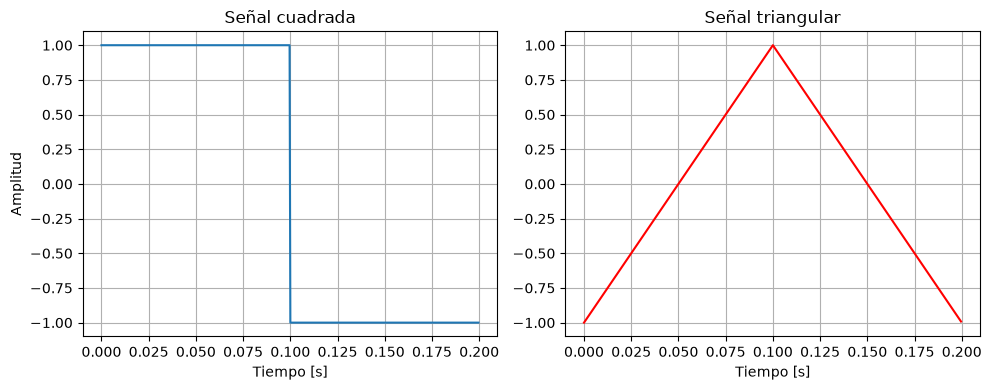

In [14]:

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(t, señal_cuadrada)
plt.title("Señal cuadrada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(t, señal_triangular, color="r")
plt.title("Señal triangular")
plt.xlabel("Tiempo [s]")
plt.grid(True)

plt.tight_layout()
plt.show()


# d y e Coeficientes de la serie de Fourier 

In [6]:

def coeficientes_fourier(señal):
    N = len(señal)
    n = np.arange(N)
    coeficientes = np.zeros(N, dtype=complex) 
    for k in range(N):
        coeficientes[k] = np.sum(señal * np.exp(-1j*2*np.pi*k*n/N)) / N
    return coeficientes

cuadrada = coeficientes_fourier(señal_cuadrada)
triangular = coeficientes_fourier(señal_triangular)


# f y g  magnitud y fase para la serie

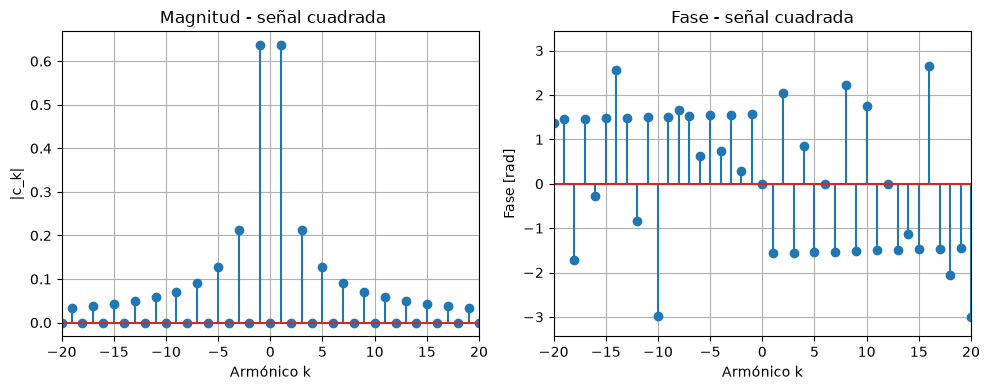

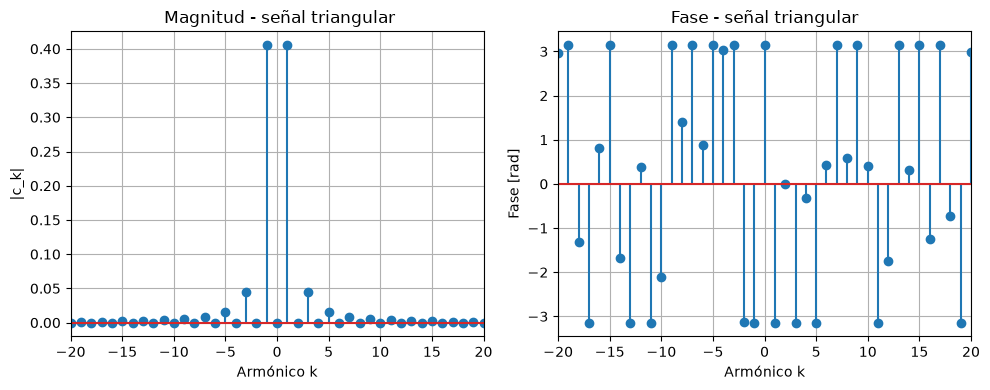

In [ ]:

def graficacion(coeficientes, titulo="", cantidad_armonicoslimite=20):
    N = len(coeficientes)
    k = np.arange(-N//2, N//2)
    coef_centrado = np.concatenate((coeficientes[N//2:], coeficientes[:N//2]))
    magnitud = np.abs(coef_centrado)
    fase = np.angle(coef_centrado)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.stem(k, magnitud)
    plt.title(f" Magnitud - {titulo}")
    plt.xlabel("Armonico k")
    plt.ylabel("|c_k|")
    plt.xlim(-cantidad_armonicoslimite, cantidad_armonicoslimite)  
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.stem(k, fase)
    plt.title(f"Fase - {titulo}")
    plt.xlabel("Armonico k")
    plt.ylabel("Fase [rad]")
    plt.xlim(-cantidad_armonicoslimite, cantidad_armonicoslimite)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

graficacion(cuadrada, "señal cuadrada")
graficacion(triangular, "señal triangular")


**Analisis:**
 en la señal cuadrada, el espectro de magnitud muestra unicamente energia en los armonicos impares k = ±1, ±3, ±5 etc, y esa magnitud decae lentamente , por lo que incluso armonicos altos siguen aportando una cantidad de energia nada despreciable esto es consecuencia directa de tener una discontinuidad latente en la señal. En la señal triangular, en cambio, la magnitud de los armonicos decae mucho más rapido, porque la señal es continua y solo tiene cambios de pendiente,mas no tiene saltos por eso con pocos armonicos ya se concentra casi toda la energia. En cuanto a la fase se tiene que en la señal cuadrada es constante en promedio sobre ±π/2 para los armónicos con magnitud distinta de cero , mientras que en la señal triangular la fase varia de forma más irregular entre armonicos, porque tal como se construyo aquí la señal no queda perfectamente simetrica respecto al instante cero.

# Puntos H e I Reconstruccion a partir de un numero finito de armonicos

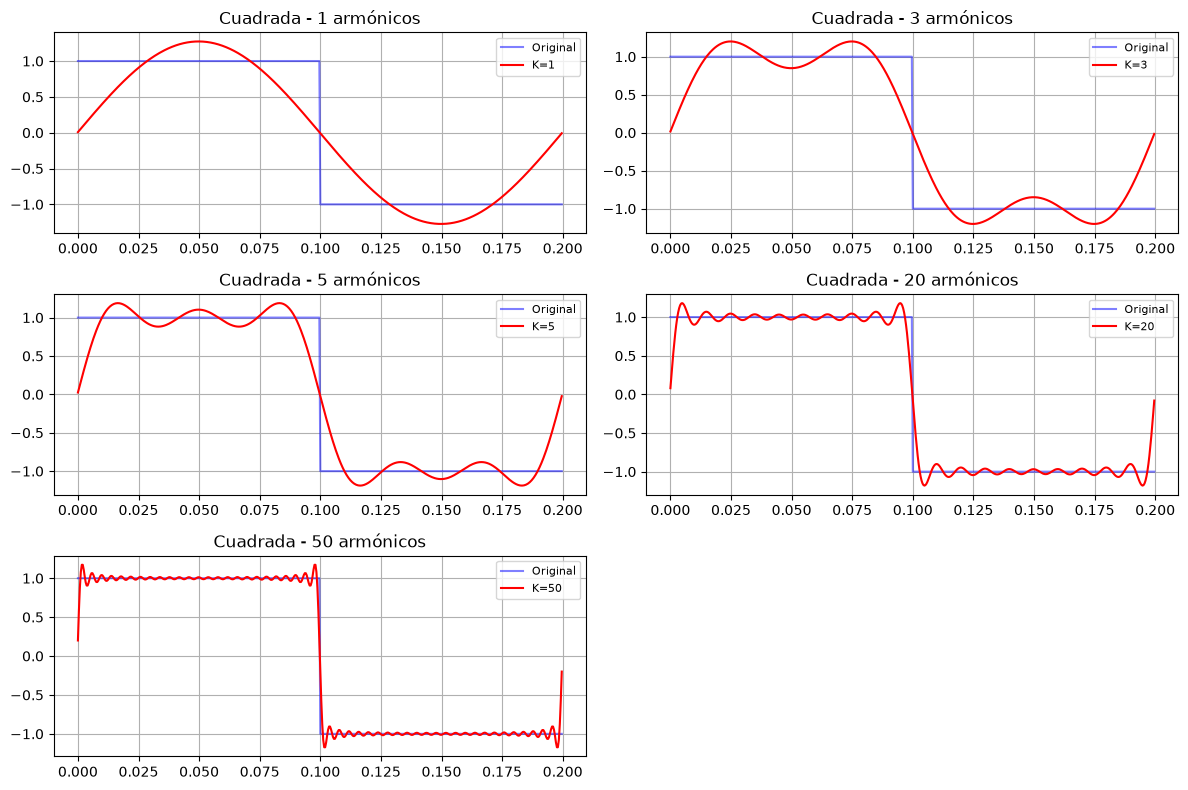

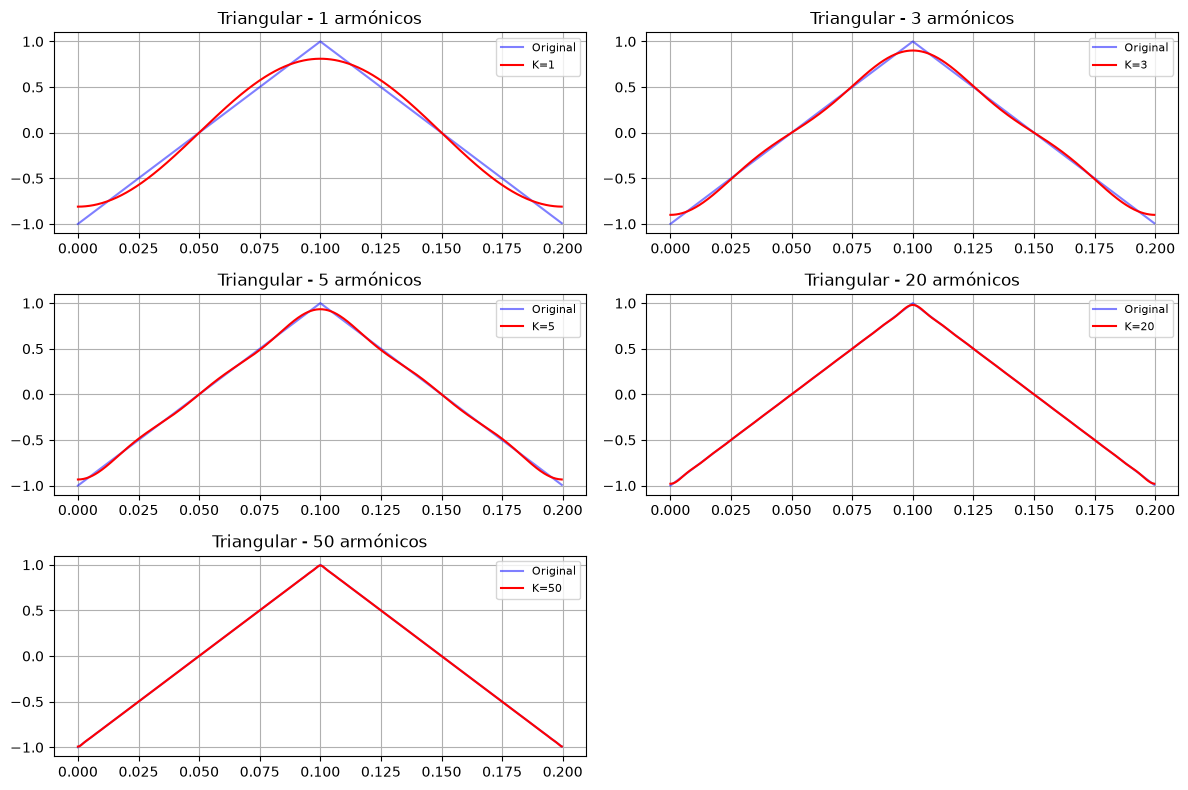

In [24]:

def reconstruir(coeficientes, n_armonicos):
    N = len(coeficientes)
    n = np.arange(N)
    reconstruccion = np.zeros(N, dtype=complex)
    for k in range(-n_armonicos, n_armonicos + 1):
        reconstruccion += coeficientes[k % N] * np.exp(1j*2*np.pi*k*n/N)
    return reconstruccion.real

#Punto i) Reconstrucción con distinto número de armónicos
armonicos = [1, 3, 5, 20, 50]

def graficar_reconstrucciones(señal_original, coeficientes, titulo=""):
    plt.figure(figsize=(12,8))
    for i, K in enumerate(armonicos, start=1):
        reconstruccion = reconstruir(coeficientes, K)
        plt.subplot(3, 2, i)
        plt.plot(t, señal_original, color="blue", alpha=0.5, label="Original")
        plt.plot(t, reconstruccion, color="r", label=f"K={K}")
        plt.title(f"{titulo} - {K} armónicos")
        plt.legend(fontsize=8)
        plt.grid(True)
    plt.tight_layout()
    plt.show()

graficar_reconstrucciones(señal_cuadrada, cuadrada, "Cuadrada")
graficar_reconstrucciones(señal_triangular, triangular, "Triangular")


**Analisis para el fenomeno de Gibbs:**
 el fenomeno de Gibbs es la oscilacion o el sobrepico que aparece en la reconstruccion de una señal con discontinuidades cuando se usa un numero determinado de armonicos, justo cerca del punto donde ocurre el salto o el punto mas alto. En la reconstruccion de la señal cuadrada se observa que con pocos armonicos como K=1, la aproximacion es apenas una onda seno suave. A medida que aumenta K =3, 5, 20, 50, la reconstruccion se ajusta cada vez mejor a los tramos planos de la señal, pero cerca de cada discontinuidad aparece un sobrepico que no desaparece ni disminuye de tamaño al aumentar el numero de armonicos. Lo unico que cambia al aumentar K es que ese sobrepico se hace mas angosto y se concentra cada vez mas cerca del punto exacto de la discontinuidad, aunque su altura se mantiene.

En la señal triangular, la cual no tiene discontinuidades, no se observa este sobrepico persistente: la reconstrucción converge de forma suave hacia la señal original a medida que aumenta K, sin oscilaciones que se mantengan. Esto confirma que el fenomeno de Gibbs es específico de señales con picos abruptos, no de cualquier esquina o cambio de pendiente.

# Punto K - Composicion espectral de ECG

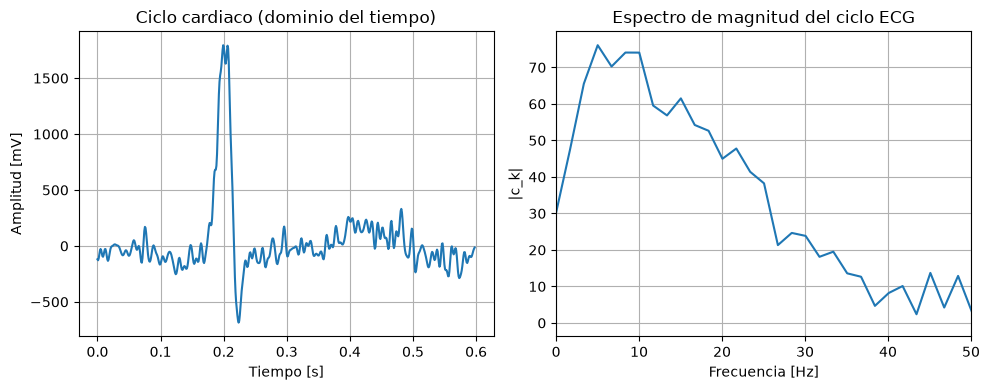

In [25]:

fs_ecg = 1024
mat_data = sio.loadmat("signals.mat")
ecg = mat_data["ECG_filtered"].squeeze()
picos, _ = find_peaks(ecg, distance=int(fs_ecg*0.6), height=np.max(ecg)*0.4)
inicio = picos[1] - int(0.2*fs_ecg)
fin = picos[1] + int(0.4*fs_ecg)
ciclo_ecg = ecg[inicio:fin]
t_ecg = np.arange(len(ciclo_ecg)) / fs_ecg

coef_ecg = coeficientes_fourier(ciclo_ecg)

N_ecg = len(coef_ecg)
k_ecg = np.arange(-N_ecg//2, N_ecg//2)
frecuencias = k_ecg * fs_ecg / N_ecg
coef_ecg_centrado = np.concatenate((coef_ecg[N_ecg//2:], coef_ecg[:N_ecg//2]))
magnitud_ecg = np.abs(coef_ecg_centrado)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(t_ecg, ciclo_ecg)
plt.title("Ciclo cardiaco (dominio del tiempo)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(frecuencias, magnitud_ecg)
plt.title("Espectro de magnitud del ciclo ECG")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|c_k|")
plt.xlim(0, 50)  
plt.grid(True)

plt.tight_layout()
plt.show()


**Analisis:**
el ancho de banda clinicamente relevante del ECG esta aproximadamente entre 0.05-100 Hz para fines diagnosticos y 0.5-40 Hz para monitoreo continuo — el espectro obtenido es coherente con esto, concentrando su energia por debajo de ~40-50 Hz. Dentro de ese rango, los distintos componentes del ciclo no aportan energia por igual, consistente con lo planteado en la teoria de esta guia:

- La onda P es una onda ancha y de variacion suave es decir sin cambios abruptosen su pendiente, por lo que su energia se concentra en frecuencias bajas, tipicamente por debajo de ~10-15 Hz.
- El complejo QRS es la porcion mas angosta y de pendiente mas pronunciada del ciclo, por lo que es el principal responsable de las componentes de frecuencia mas alta presentes en el ECG.
- La onda T, al igual que la onda P, es ancha y sin cambios abruptos en su pendiente por lo que tambien concentra su energia en frecuencias bajas.
